<a href="https://colab.research.google.com/github/nihaarsatsangi12/pepper-leaf-disease-detection/blob/main/pepper_leaf_disease_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 1: Install Kaggle API and Authenticate
!pip install kaggle
from google.colab import files

In [2]:
# Upload your kaggle.json file
files.upload()

# Move the kaggle.json file to the .kaggle directory
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [3]:
# Step 2: Download Dataset from Kaggle
# Replace 'plant-village/PlantVillage' with the actual Kaggle dataset name
!kaggle datasets download -d arjuntejaswi/plant-village

Dataset URL: https://www.kaggle.com/datasets/arjuntejaswi/plant-village
License(s): unknown
100% 329M/329M [00:04<00:00, 82.8MB/s]



In [4]:
!unzip plant-village.zip -d dataset

Streaming output truncated to the last 5000 lines.
  inflating: dataset/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08c033bd-fbc3-445a-88d1-1863070e52ce___YLCV_GCREC 2872.JPG  
  inflating: dataset/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08dd176c-e9d9-4746-92c3-fa8dc9074347___UF.GRC_YLCV_Lab 03057.JPG  
  inflating: dataset/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08f78a80-46f5-45a6-937c-4d05d61c08c2___UF.GRC_YLCV_Lab 01895.JPG  
  inflating: dataset/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0903aa95-6e8a-4abd-a003-126fcd9a5493___YLCV_GCREC 2806.JPG  
  inflating: dataset/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0911d416-d73d-4c2a-8e45-207a7ceb7c9a___YLCV_GCREC 2773.JPG  
  inflating: dataset/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/09188838-cc89-4925-94c5-d9563c4cb4bf___UF.GRC_YLCV_Lab 02974.JPG  
  inflating: dataset/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0922e026-b563-438d-b9ed-7476153023ce___YLCV_GCREC 2258.JPG  


In [5]:
!mkdir dataset-selected
!mv dataset/PlantVillage/Pepper* dataset-selected/

In [6]:
!rm -r dataset

In [7]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import os

# Step 3: Set Path to Dataset and Load Dataset
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 50

#dataset_path = "dataset/PlantVillage"  # Path where dataset is extracted
dataset_path = "dataset-selected"

# Split by file, once, so no image can be in two sets
train_ds, holdout_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="both",
    seed=123,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Class Names:", class_names)

# Half of the held-out 20% for validation, half for testing
holdout_batches = len(holdout_ds)
val_ds = holdout_ds.take(holdout_batches // 2)
test_ds = holdout_ds.skip(holdout_batches // 2)

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# dataset = tf.keras.preprocessing.image_dataset_from_directory(
#     dataset_path,
#     seed=123,
#     shuffle=True,
#     image_size=(IMAGE_SIZE, IMAGE_SIZE),
#     batch_size=BATCH_SIZE
# )


Found 2475 files belonging to 2 classes.
Using 1980 files for training.
Using 495 files for validation.
Class Names: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy']


In [8]:
# # Display class names
# class_names = dataset.class_names
# print("Class Names:", class_names)

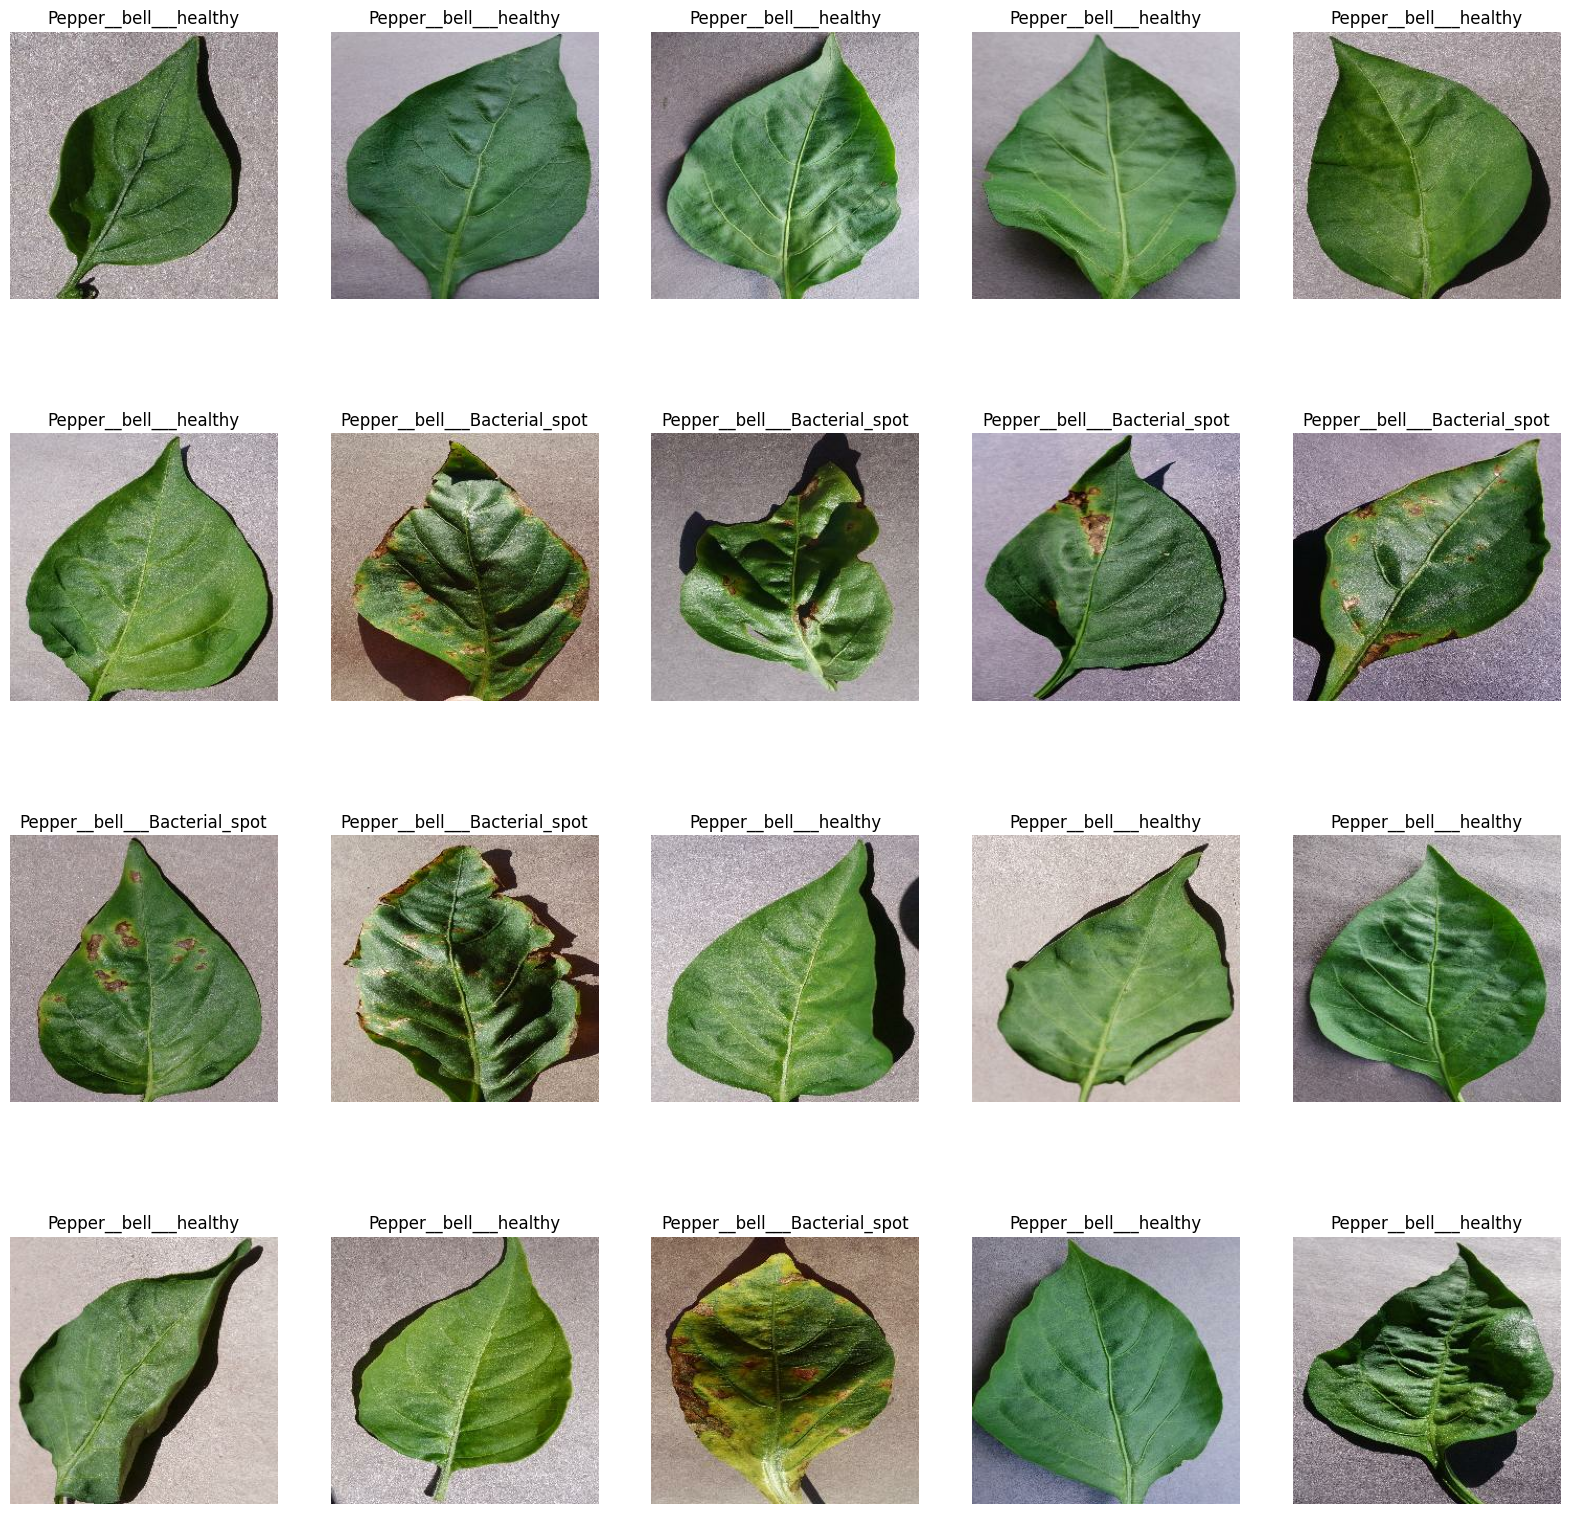

In [9]:
# Visualize Some Images
plt.figure(figsize=(20, 20))
# for image_batch, labels_batch in dataset.take(1):
for image_batch, labels_batch in train_ds.take(1):  # Use train_dataset or val_dataset
    for i in range(20):
        ax = plt.subplot(4, 5, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")
plt.show()



In [10]:
# Step 4: Partition Dataset
# def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
#     ds_size = len(ds)
#     if shuffle:
#         ds = ds.shuffle(shuffle_size, seed=12)

#     train_size = int(train_split * ds_size)
#     val_size = int(val_split * ds_size)

#     train_ds = ds.take(train_size)
#     val_ds = ds.skip(train_size).take(val_size)
#     test_ds = ds.skip(train_size).skip(val_size)

#     return train_ds, val_ds, test_ds

# train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

# # Optimize Dataset Pipelines
# train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
# val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
# test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

# Preprocessing Layers
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0 / 255)
])

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])


In [11]:
# Step 5: Build and Train the Model
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = len(class_names)

model = models.Sequential([
    layers.InputLayer(input_shape=input_shape),
    resize_and_rescale,
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),# YAHANA TAK WE HAVE IMAGE ONLY
    layers.Flatten(), # YHANA WE CONVERTING IT TO nX1.......... EK STRAIGHT LINE M JAISE
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,682 (717.51 KB)

 Trainable params: 183,682 (717.51 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer='adam', #REOPLACEMENT FOR GRAD DECEND
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), # THIS IS MY COST FUNCTION
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    verbose=1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 29s 256ms/step - accuracy: 0.6298 - loss: 0.6431 - val_accuracy: 0.7617 - val_loss: 0.5080
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.8707 - loss: 0.3364 - val_accuracy: 0.9453 - val_loss: 0.1511
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.9470 - loss: 0.1811 - val_accuracy: 0.9570 - val_loss: 0.0878
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.9742 - loss: 0.0901 - val_accuracy: 0.9883 - val_loss: 0.0712
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.9823 - loss: 0.0602 - val_accuracy: 0.9766 - val_loss: 0.0665
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.9949 - loss: 0.0279 - val_accuracy: 0.9922 - val_loss: 0.0200
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.9955 - loss: 0.0284 - val_accuracy: 1.0000 - val_loss: 0.0058
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.9919 - loss: 0.0288 - val_accuracy: 0.9922 -

In [13]:
score = model.evaluate(test_ds) #testing our model

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 247ms/step - accuracy: 0.9958 - loss: 0.0452


In [14]:
score  #[loss,accuracy]

[0.04519173875451088, 0.9958158731460571]

In [15]:
history

In [16]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 62}

In [17]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [18]:
history.history['accuracy']

[0.6297979950904846,
 0.870707094669342,
 0.9469696879386902,
 0.9742424488067627,
 0.9823232293128967,
 0.9949495196342468,
 0.9954545497894287,
 0.991919219493866,
 0.997474730014801,
 0.9964646697044373,
 0.9858585596084595,
 0.9949495196342468,
 0.9959595799446106,
 0.9969696998596191,
 0.9969696998596191,
 0.9964646697044373,
 0.9989898800849915,
 0.9979798197746277,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0]

In [19]:
len(history.history['accuracy'])

50

In [20]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

Text(0.5, 1.0, 'training and validation loss')

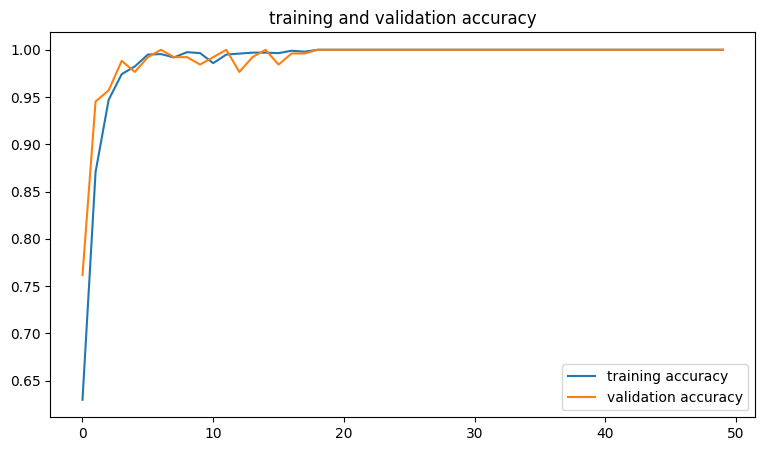

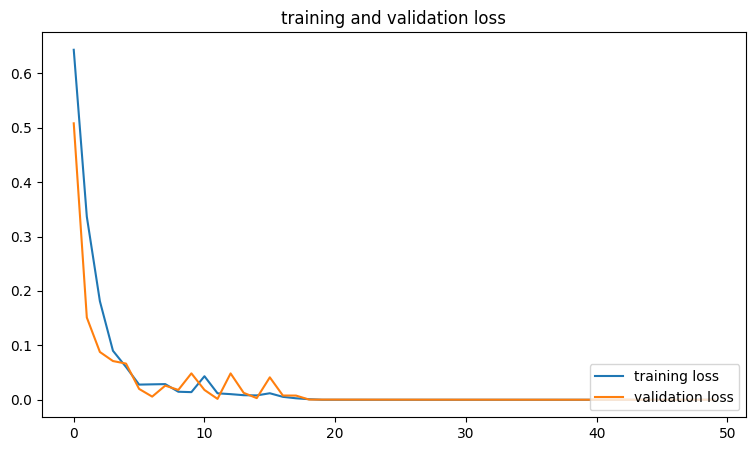

In [25]:
#plotting training and validation

plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), acc, label = 'training accuracy')
plt.plot(range(EPOCHS), val_acc, label = 'validation accuracy')
plt.legend(loc = 'lower right')
plt.title('training and validation accuracy')


plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), loss, label = 'training loss')
plt.plot(range(EPOCHS), val_loss, label = 'validation loss')
plt.legend(loc = 'lower right')
plt.title('training and validation loss')



In [22]:
model.save("plant_disease_model.h5")

from google.colab import files
files.download("plant_disease_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
model.save("plant_disease_model-1.keras")

from google.colab import files
files.download("plant_disease_model-1.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>